### Explicación del dataset

EuroSAT es una elección muy buena para justificar decisiones arquitectónicas — imágenes satelitales RGB de 64x64px con 10 clases (bosques, ríos, carreteras, zonas industriales, etc.).

### Cargamos el dataset

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Definimos las transformaciones que se aplican a las imágenes
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Redimensiona las imágenes a 64x64 (característica de este dataset)
    transforms.ToTensor()         # Convierte las imágenes a tensores
])

# Cargamos el dataset EuroSAT
trainset = torchvision.datasets.EuroSAT(
    root='./data',       # carpeta donde se guardan los datos
    download=True,       # descarga el dataset si no existe
    transform=transform  # aplica las transformaciones
)

# EuroSAT no viene separado en train/test, así que lo dividimos manualmente
from torch.utils.data import random_split

# Calculamos tamaño del conjunto de entrenamiento (80%)
train_size = int(0.8 * len(trainset))

# El resto será el conjunto de test (20%)
test_size = len(trainset) - train_size

# Dividimos el dataset en train y test
trainset, testset = random_split(trainset, [train_size, test_size])

# Tamaño de lote (cuántas imágenes se procesan a la vez)
batch_size = 32

# DataLoader para el entrenamiento (mezcla los datos)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

# DataLoader para test (no se mezclan los datos)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

### Clase del Dataset

In [16]:
class EuroSATModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3, 3), stride=1, padding=1) #3 canales, 32 características, kernel_size de 3x3
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.pool1 = nn.MaxPool2d(2, 2) #tamaño del kernel de 2x2

        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=1, padding=1) #32 de entrada, 32 características, kernel_size de 3x3
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.pool2 = nn.MaxPool2d(2,2)

        self.flat = nn.Flatten()

        self.fc3 = nn.Linear(8192, 512)
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):
        #input 3x32x32 - output 32x32x32
        x = self.act1(self.conv1(x))
        x = self.drop1(x)

        #input 32x32x32 - output 32x16x16
        x = self.pool1(x)

        # input 32x16x16-output 32x16x16
        x = self.act2(self.conv2(x))
        x = self.drop2(x)

        #input 32x16x16 - output 32x8x8
        x = self.pool2(x)

        #input 32x8x8 - output 2048
        x = self.flat(x)

        x = self.act3(self.fc3(x))
        x = self.drop3(x)

        x = self.fc4(x)
        return x


### Entrenamiento del dataset

In [6]:
import torch.optim as optim

model = EuroSATModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

n_epochs = 10
for epoch in range(n_epochs):
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        y_pred = model(inputs)
        loss = loss_fn(y_pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    acc = 0
    count = 0
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        y_pred = model(inputs)
        acc += (torch.argmax(y_pred, 1) == labels).float().sum()
        count += len(labels)
    acc = acc/count
    print("Época %d: accuracy del modelo %.2f%%" % (epoch, acc*100))

torch.save(model.state_dict(), 'eurosat_model.pth')

cpu
Época 0: accuracy del modelo 54.35%
Época 1: accuracy del modelo 66.30%
Época 2: accuracy del modelo 69.43%
Época 3: accuracy del modelo 65.06%
Época 4: accuracy del modelo 70.41%
Época 5: accuracy del modelo 69.65%
Época 6: accuracy del modelo 71.37%
Época 7: accuracy del modelo 73.65%
Época 8: accuracy del modelo 72.22%
Época 9: accuracy del modelo 72.96%


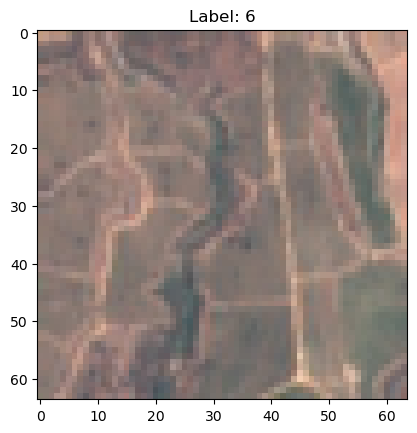

In [17]:
import matplotlib.pyplot as plt

# Cogemos una imagen del dataset
image, label = trainset[4]

# Cambiamos el formato de la imagen de (Canales, Alto, Ancho)
# a (Alto, Ancho, Canales) para poder mostrarla
image = image.permute(1, 2, 0)

# Mostramos la imagen
plt.imshow(image)

# Ponemos el título con la etiqueta de la imagen
plt.title(f"Label: {label}")

# Mostramos la figura
plt.show()

In [19]:
import torch

# Cogemos una imagen del dataset
X, label = trainset[7]

# Añadimos una dimensión extra para batch (1 imagen)
# De (C, H, W) pasa a (1, C, H, W)
X = X.unsqueeze(0)

# Ponemos el modelo en modo evaluación
model.eval()

# Elegimos si usar GPU (cuda) o CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Movemos la imagen al mismo dispositivo que el modelo
X = X.to(device)

# Movemos el modelo al dispositivo
model = model.to(device)

# Desactivamos el cálculo de gradientes (más rápido y eficiente)
with torch.no_grad():
    # Hacemos la predicción
    y_pred = model(X)
    
    # Nos quedamos con la clase con mayor probabilidad
    pred_class = torch.argmax(y_pred, dim=1)

# Mostramos la clase real
print("Clase real:", label)

# Mostramos la predicción del modelo
print("Predicción:", pred_class.item())

Clase real: 4
Predicción: 4


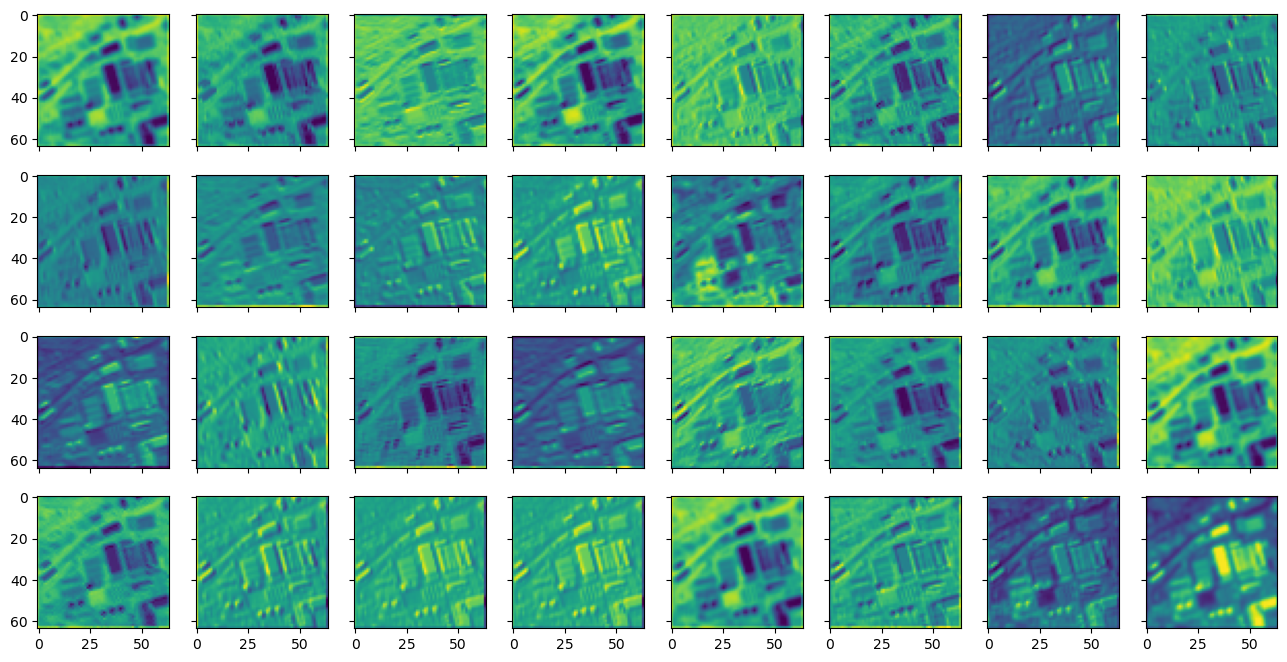

In [23]:
# Desactivamos el cálculo de gradientes (solo queremos ver resultados)
with torch.no_grad():
    # Pasamos la imagen por la primera capa convolucional del modelo
    feature_maps = model.conv1(X.to(device))

# Creamos una cuadrícula de 4 filas y 8 columnas para mostrar los mapas
fig, ax = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(16, 8))

# Recorremos los 32 mapas de características
for i in range(0, 32):
    # Calculamos fila y columna en la cuadrícula
    row, col = i // 8, i % 8
    
    # Mostramos cada mapa de características
    ax[row][col].imshow(feature_maps[0][i].cpu().numpy())

# Mostramos la figura final
plt.show()

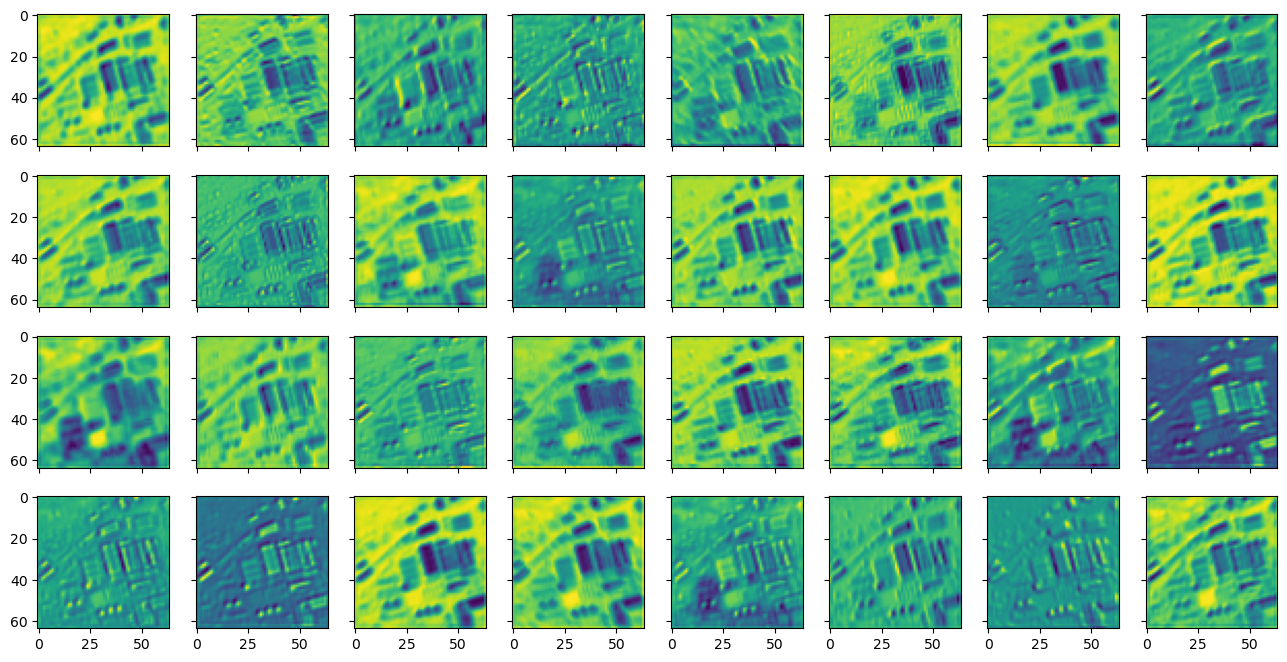

In [24]:
# Desactivamos gradientes porque solo queremos visualizar (no entrenar)
with torch.no_grad():
    
    # Pasamos la imagen por la primera convolución
    feature_maps = model.conv1(X.to(device))
    
    # Aplicamos la función de activación (ReLU u otra)
    feature_maps = model.act1(feature_maps)
    
    # Aplicamos dropout (apaga algunas neuronas aleatoriamente)
    feature_maps = model.drop1(feature_maps)
    
    # Pasamos por la segunda capa convolucional
    feature_maps = model.conv2(feature_maps)

# Creamos una cuadrícula para mostrar los mapas de características
fig, ax = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(16, 8))

# Mostramos los 32 feature maps
for i in range(0, 32):
    row, col = i // 8, i % 8
    
    # Pasamos a CPU y lo convertimos a numpy para poder visualizar
    ax[row][col].imshow(feature_maps[0][i].cpu().numpy())

# Mostramos la figura
plt.show()